In [12]:
# Install necessary libraries
!pip install catboost bayesian-optimization

In [13]:
# Import libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from catboost import CatBoostRegressor
from bayes_opt import BayesianOptimization
import matplotlib.pyplot as plt

In [14]:
# Load and preprocess the dataset
data = pd.read_csv('/content/Final_Cleaned_Voyage_Data.csv', parse_dates=['DepartureTime', 'ArrivalTime'], infer_datetime_format=True)

# Convert datetimes and calculate duration
data['DepartureTime'] = pd.to_datetime(data['DepartureTime'], format="%m/%d/%Y %H:%M")
data['ArrivalTime'] = pd.to_datetime(data['ArrivalTime'], format="%m/%d/%Y %H:%M")
data['TravelTime_seconds'] = (data['ArrivalTime'] - data['DepartureTime']).dt.total_seconds()

# Extract departure hour
data['DepartureHour'] = data['DepartureTime'].dt.hour

# Define features and target variable
features = ['LATd', 'LONd', 'LATa', 'LONa', 'Voyage_Distance_Km', 'draft_km', 'Average_Speed_Kmph',
            'Std_SpeedKMpH', 'Avg_Course', 'breadthKM', 'DepartureHour', 'vessel_type']
target = 'TravelTime_seconds'

<ipython-input-14-6b9069eb52ab>:2: FutureWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  data = pd.read_csv('/content/Final_Cleaned_Voyage_Data.csv', parse_dates=['DepartureTime', 'ArrivalTime'], infer_datetime_format=True)


In [15]:
# Split data into train and test sets
train_data, test_data = train_test_split(data[features + [target]], test_size=0.2, random_state=42)

# Separate features and target
X_train, y_train = train_data[features], train_data[target]
X_test, y_test = test_data[features], test_data[target]

In [16]:
# Bayesian Optimization for Hyperparameter Tuning
def catboost_hyperopt(iterations, learning_rate, depth, l2_leaf_reg):
    """
    Objective function for Bayesian Optimization.
    """
    # Convert hyperparameters to appropriate types
    iterations = int(iterations)
    depth = int(depth)

    # Initialize and train the CATBoost model
    model = CatBoostRegressor(
        iterations=iterations,
        learning_rate=learning_rate,
        depth=depth,
        l2_leaf_reg=l2_leaf_reg,
        loss_function='MAE',
        random_state=42,
        verbose=0
    )

    # Fit the model
    model.fit(X_train, y_train, cat_features=['vessel_type'])

    # Predict on the validation set (using a subset of the training data for faster evaluation)
    y_pred = model.predict(X_test)

    # Use negative MAE as the objective (Bayesian Optimization maximizes the objective)
    return -mean_absolute_error(y_test, y_pred)

# Define the parameter bounds for Bayesian Optimization
param_bounds = {
    'iterations': (100, 200),  # Number of boosting iterations
    'learning_rate': (0.01, 0.1),  # Learning rate
    'depth': (4, 10),  # Depth of the trees
    'l2_leaf_reg': (1, 10)  # L2 regularization term
}

# Initialize Bayesian Optimization
optimizer = BayesianOptimization(
    f=catboost_hyperopt,
    pbounds=param_bounds,
    random_state=42
)

# Perform optimization
optimizer.maximize(init_points=5, n_iter=10)  # Adjust init_points and n_iter as needed

# Print the best hyperparameters
best_params = optimizer.max['params']
print("Best Hyperparameters from Bayesian Optimization:")
print(best_params)

|   iter    |  target   |   depth   | iterat... | l2_lea... | learni... |
-------------------------------------------------------------------------
| 1         | -1.048e+0 | 6.247     | 195.1     | 7.588     | 0.06388   |
| 2         | -1.784e+0 | 4.936     | 115.6     | 1.523     | 0.08796   |
| 3         | -1.001e+0 | 7.607     | 170.8     | 1.185     | 0.09729   |
| 4         | -3.091e+0 | 8.995     | 121.2     | 2.636     | 0.02651   |
| 5         | -2.347e+0 | 5.825     | 152.5     | 4.888     | 0.03621   |
| 6         | -1.059e+0 | 6.36      | 195.1     | 7.853     | 0.06155   |
| 7         | -1.311e+0 | 6.422     | 180.6     | 3.032     | 0.04856   |
| 8         | -9.901e+0 | 9.176     | 172.2     | 9.594     | 0.08004   |
| 9         | -1.552e+0 | 9.933     | 199.4     | 1.117     | 0.02953   |
| 10        | -4.86e+04 | 4.135     | 101.5     | 2.631     | 0.02998   |
| 11        | -1.424e+0 | 4.083     | 164.4     | 9.204     | 0.07752   |
| 12        | -1.079e+0 | 9.858     | 

In [17]:
# Train the final model with the best hyperparameters
best_model = CatBoostRegressor(
    iterations=int(best_params['iterations']),
    learning_rate=best_params['learning_rate'],
    depth=int(best_params['depth']),
    l2_leaf_reg=best_params['l2_leaf_reg'],
    loss_function='MAE',
    random_state=42,
    verbose=100
)

# Fit the best model
best_model.fit(X_train, y_train, cat_features=['vessel_type'])

# Predict on the test set
y_pred_best = best_model.predict(X_test)

# Evaluate the best model
mae_best = mean_absolute_error(y_test, y_pred_best)
mse_best = mean_squared_error(y_test, y_pred_best)
r2_best = r2_score(y_test, y_pred_best)

print("\nBest Model Performance:")
print("Mean Absolute Error:", mae_best)
print("Mean Squared Error:", mse_best)
print("R-squared:", r2_best)

0:	learn: 173205.6082491	total: 30.3ms	remaining: 5.18s
100:	learn: 12684.1219221	total: 3.05s	remaining: 2.14s
171:	learn: 8835.8308723	total: 4.98s	remaining: 0us

Best Model Performance:
Mean Absolute Error: 9900.5382612734
Mean Squared Error: 1525174464.3992324
R-squared: 0.9887377669967089


In [18]:
# K-Fold Cross-Validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)

def evaluate_model(X, y, kf):
    mae_scores = []
    mse_scores = []
    r2_scores = []

    for train_index, test_index in kf.split(X):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]

        # Train CATBoost model with best hyperparameters
        model = CatBoostRegressor(
            iterations=int(best_params['iterations']),
            learning_rate=best_params['learning_rate'],
            depth=int(best_params['depth']),
            l2_leaf_reg=best_params['l2_leaf_reg'],
            loss_function='MAE',
            random_state=42,
            verbose=0
        )
        model.fit(X_train, y_train, cat_features=['vessel_type'])

        # Predict on the test set
        y_pred = model.predict(X_test)

        # Calculate metrics
        mae_scores.append(mean_absolute_error(y_test, y_pred))
        mse_scores.append(mean_squared_error(y_test, y_pred))
        r2_scores.append(r2_score(y_test, y_pred))

    return mae_scores, mse_scores, r2_scores

# Perform K-Fold Cross-Validation
mae_scores, mse_scores, r2_scores = evaluate_model(data[features], data[target], kf)

# Print results
print(f'MAE Scores: {mae_scores}')
print(f'MSE Scores: {mse_scores}')
print(f'R2 Scores: {r2_scores}')
print(f'Mean MAE: {sum(mae_scores)/len(mae_scores)}')
print(f'Mean MSE: {sum(mse_scores)/len(mse_scores)}')
print(f'Mean R2: {sum(r2_scores)/len(r2_scores)}')

MAE Scores: [9899.711803962473, 10436.8703666786, 11010.517840860992, 9853.33476752092, 9677.386420426545]
MSE Scores: [1544918355.1849828, 1595323894.808817, 1352549103.3771265, 1239450527.3170712, 1217468093.5338483]
R2 Scores: [0.9885919736441379, 0.9889128705398258, 0.990760188327862, 0.9908481957772312, 0.991616999523683]
Mean MAE: 10175.564239889907
Mean MSE: 1389941994.8443692
Mean R2: 0.9901460455625479


In [19]:
# Mean Absolute Percentage Error (MAPE)
def mean_absolute_percentage_error(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    non_zero_indices = y_true != 0
    y_true_non_zero = y_true[non_zero_indices]
    y_pred_non_zero = y_pred[non_zero_indices]
    return np.mean(np.abs((y_true_non_zero - y_pred_non_zero) / y_true_non_zero)) * 100

# Compute MAPE for the best model
catboost_mape = mean_absolute_percentage_error(y_test, y_pred_best)
print(f"CATBoost MAPE: {catboost_mape:.2f}%")

CATBoost MAPE: 1.73%


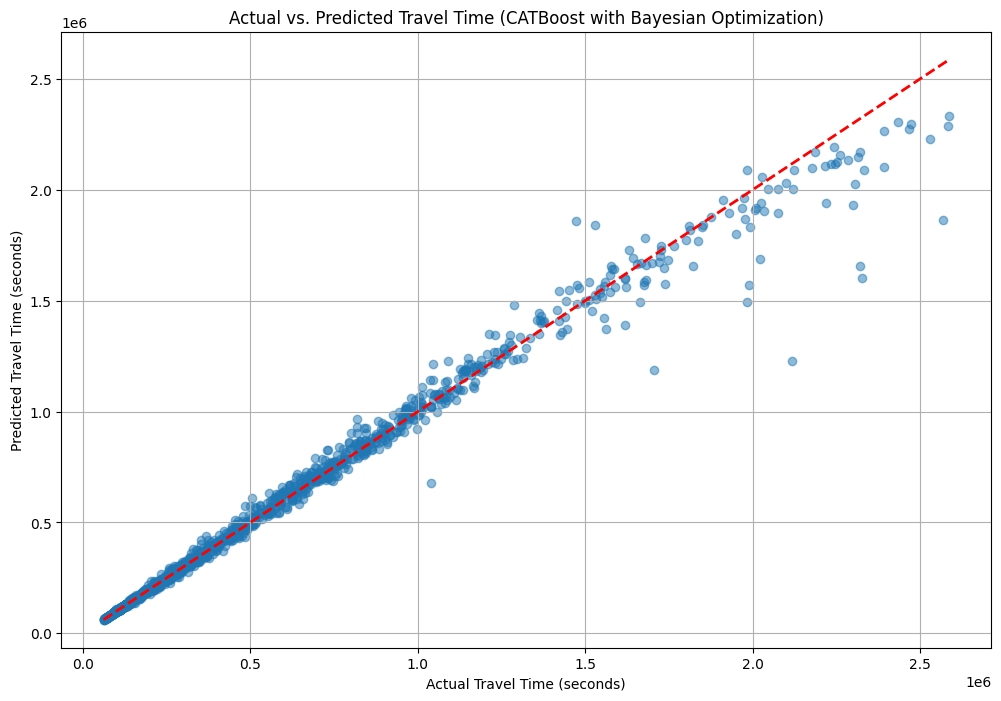

In [20]:
# Plot Actual vs. Predicted
plt.figure(figsize=(12, 8))
plt.scatter(y_test, y_pred_best, alpha=0.5)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], 'r--', lw=2)
plt.title('Actual vs. Predicted Travel Time (CATBoost with Bayesian Optimization)')
plt.xlabel('Actual Travel Time (seconds)')
plt.ylabel('Predicted Travel Time (seconds)')
plt.grid(True)
plt.show()

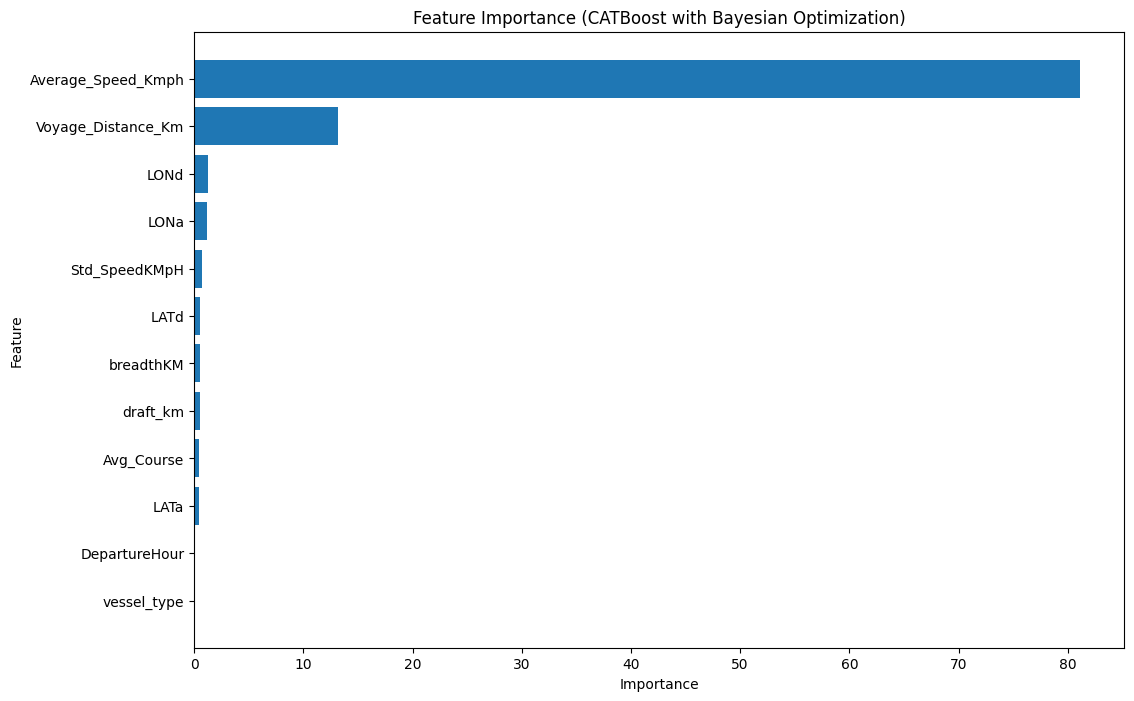

In [23]:
# Feature Importance
feature_importance = best_model.get_feature_importance()
feature_names = X_train.columns

# Sort feature importance and feature names in ascending order
sorted_indices = np.argsort(feature_importance)  # Get indices for sorting
sorted_feature_importance = feature_importance[sorted_indices]  # Sort importance values
sorted_feature_names = feature_names[sorted_indices]  # Sort feature names

# Plot Feature Importance in ascending order
plt.figure(figsize=(12, 8))
plt.barh(sorted_feature_names, sorted_feature_importance)
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Feature Importance (CATBoost with Bayesian Optimization)')
plt.show()